# **Equipo "The two powerpuff girls and Kevin"**
### conformado por:
### Kevin Leonardo Baños Sánchez
### Itzel Alejandra Lesama Apolinar
### Norma Inés Llergo Sánchez


## **Objetivo: catalogar cuántas personas de EU tienen diabetes.**
## **Realizar un análisis exploratorio de datos (EDA) con visualizaciones como histogramas, boxplots y gráficos de dispersión, e interpretar las relaciones entre las diferentes características del conjunto de datos dados de Diabetes proporcionados por NIDDK.**

--------------------------------------------------------------------

# **Proyecto SIC limpieza y análisis exploratorio del conjunto de datos de predicción de la diabetes**

## 1.0 Primero hay que importar nuestras librerías

In [2]:
import pandas as pd #nos ayudará a limpiar, preparar, analizar y limpiar los datos
import numpy as np  #esta librería nos ayudará para manejar los datos con arreglos bidimensionales
import matplotlib.pyplot as plt #es importante porque nos ayuda a graficar los datos que tenemos
import seaborn as sns #nos ayudará también a graficar con ayuda de matplotlib
%matplotlib inline
#ayuda a que los gráficos realizados se muestren cada que hay un bloque de nuestro código

## 2.0 Obtenemos el conjunto de datos de diabetes desde seaborn

In [3]:
df= pd.read_csv('diabetes2.csv'); #cargamos nuestro archivo de dataset

## 3.0 Exploración inicial de datos

### 3.1 Visualizamos las primeras filas del dataset usando head().

In [4]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df.info(); #vemos que no hay valores nulos, por tanto no ocupamos hacer limpieza, nos llama la atención que haya valores
# booleanos tomados como enteros, por ejemplo en smoking se tienen 0's y 1's

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


### 3.3 Generamos estadísticas descriptivas de las características numéricas con describe().

In [6]:
df.describe() #descripcion de nuestro dataset

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## 4.0 Identificación y manejo de datos faltantes

### 4.1 Verifica si existen valores faltantes con isnull().sum().

In [7]:
print((df.isnull()).sum(axis=0)) #tenemos que la suma de los valores nulos es 0 por tanto no hay

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [8]:
mapping = {'Male': 1, 'Female': 0, 'M': 1, 'F': 0}

df['gender'] = df['gender'].map(mapping)

print(df['gender'].head()) 

0    0.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: gender, dtype: float64


### 4.2 No fue necesaria la imputación de datos ya que no hubo valores nulos

## 5.0 Detección y Tratamiento de Valores Atípicos (Outliers)

### 5.1 Utilizamos boxplots para identificar posibles outliers en las columnas numéricas.

#### Nota: descartamos id, gender, smoking, physical_activity, alcohol_intake, family_history, diabetes.

#### Utilizamos: age, bmi, glucose, blood_pressure, cholesterol, heart_rate, sleep_hours, steps_per_day, work_hours, winter_intake_ltr, insulin.

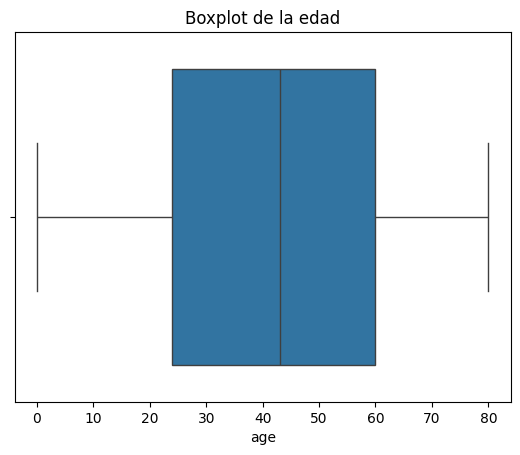

100000


In [9]:
sns.boxplot(x=df['age']);
plt.title('Boxplot de la edad');
plt.show();
print(len(df['age']));

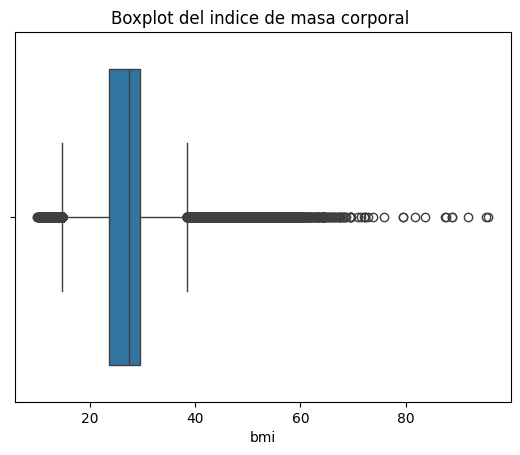

100000


In [10]:
sns.boxplot(x=df['bmi']);
plt.title('Boxplot del indice de masa corporal ');
plt.show();
print(len(df['bmi']));

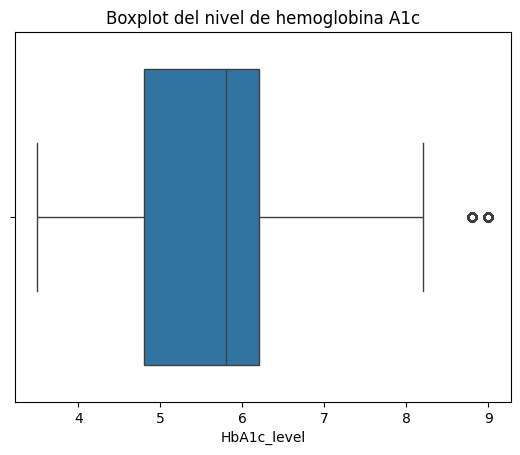

100000


In [11]:
sns.boxplot(x=df['HbA1c_level']);
plt.title('Boxplot del nivel de hemoglobina A1c');
plt.show();
print(len(df['HbA1c_level']));

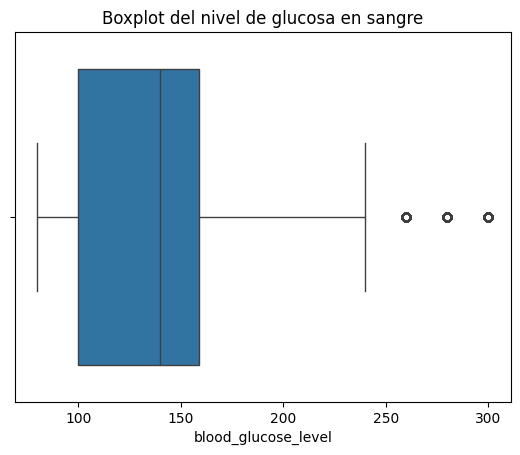

100000


In [12]:
sns.boxplot(x=df['blood_glucose_level']);
plt.title('Boxplot del nivel de glucosa en sangre');
plt.show();
print(len(df['blood_glucose_level']));

## 6 Visualización de datos

### 6.0 Estandarización de datos

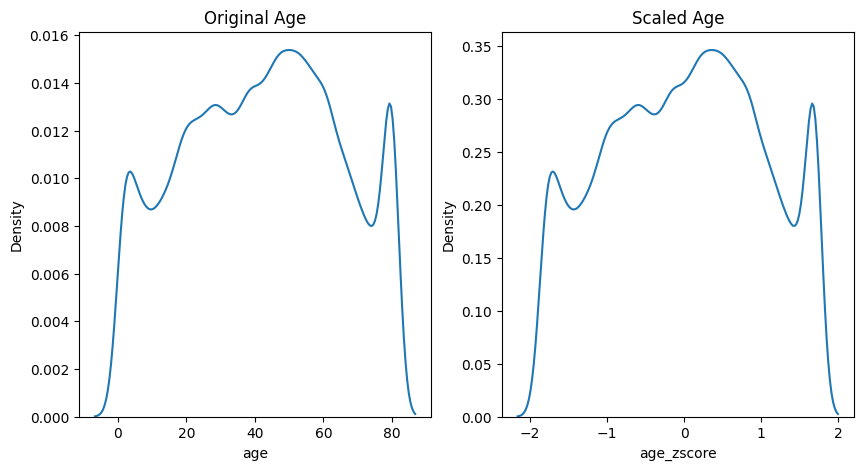

In [13]:
df['age_zscore'] = (df['age'] - df['age'].mean()) / df['age'].std() #obtenemos z estadística = (x-u)/s
# grafica antes y despues
fig, ax = plt.subplots(1, 2, figsize=(10, 5));
sns.kdeplot(df['age'], ax=ax[0]);
ax[0].set_title('Original Age');
sns.kdeplot(df['age_zscore'], ax=ax[1])
ax[1].set_title('Scaled Age')
plt.show()

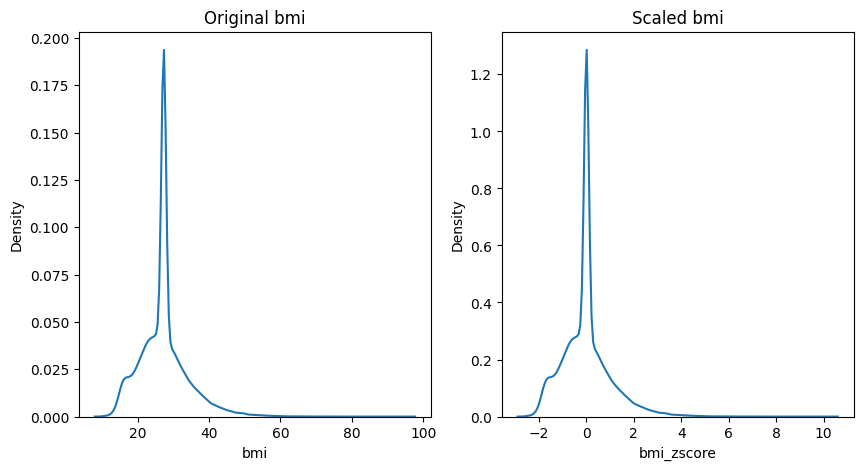

In [14]:
df['bmi_zscore'] = (df['bmi'] - df['bmi'].mean()) / df['bmi'].std() #obtenemos z estadística = (x-u)/s
# grafica antes y despues
fig, ax = plt.subplots(1, 2, figsize=(10, 5));
sns.kdeplot(df['bmi'], ax=ax[0]);
ax[0].set_title('Original bmi');
sns.kdeplot(df['bmi_zscore'], ax=ax[1])
ax[1].set_title('Scaled bmi')
plt.show()

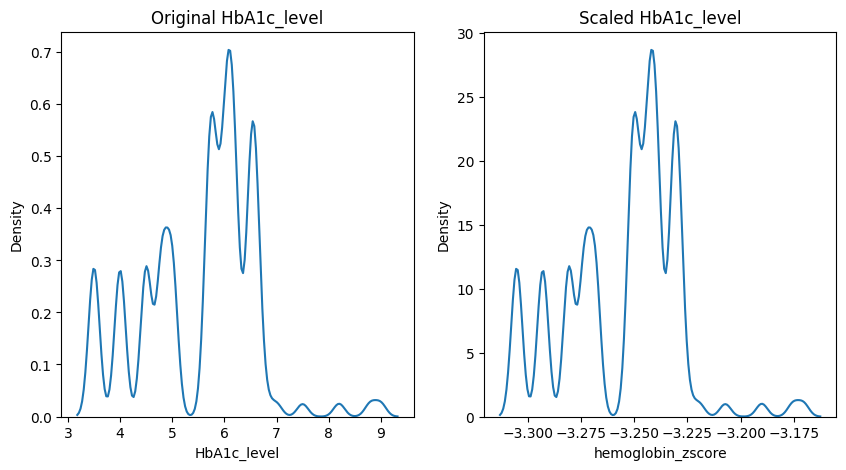

In [15]:
df['hemoglobin_zscore'] = (df['HbA1c_level'] - df['blood_glucose_level'].mean()) / df['blood_glucose_level'].std() #obtenemos z estadística = (x-u)/s
# grafica antes y despues
fig, ax = plt.subplots(1, 2, figsize=(10, 5));
sns.kdeplot(df['HbA1c_level'], ax=ax[0]);
ax[0].set_title('Original HbA1c_level');
sns.kdeplot(df['hemoglobin_zscore'], ax=ax[1])
ax[1].set_title('Scaled HbA1c_level')
plt.show()

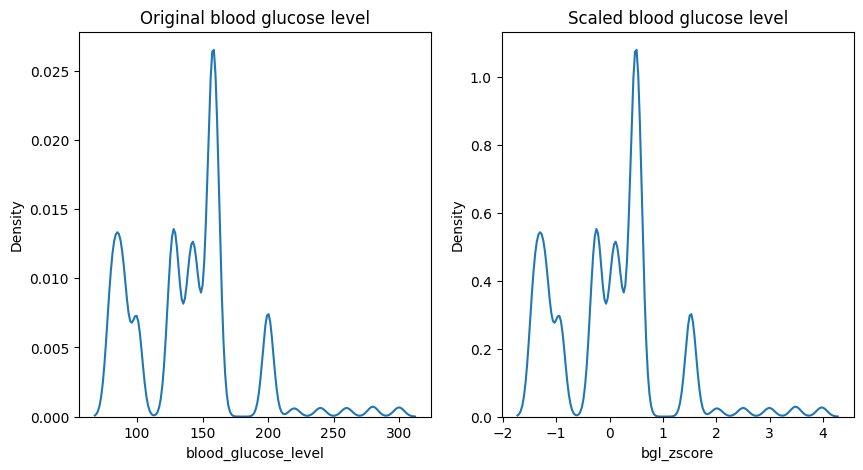

In [16]:
df['bgl_zscore'] = (df['blood_glucose_level'] - df['blood_glucose_level'].mean()) / df['blood_glucose_level'].std() #obtenemos z estadística = (x-u)/s
# grafica antes y despues
fig, ax = plt.subplots(1, 2, figsize=(10, 5));
sns.kdeplot(df['blood_glucose_level'], ax=ax[0]);
ax[0].set_title('Original blood glucose level');
sns.kdeplot(df['bgl_zscore'], ax=ax[1])
ax[1].set_title('Scaled blood glucose level')
plt.show()

### 6.1 Histogramas para cada característica numérica.

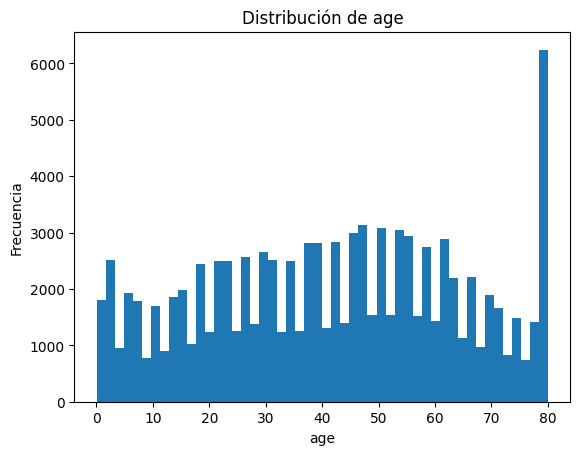

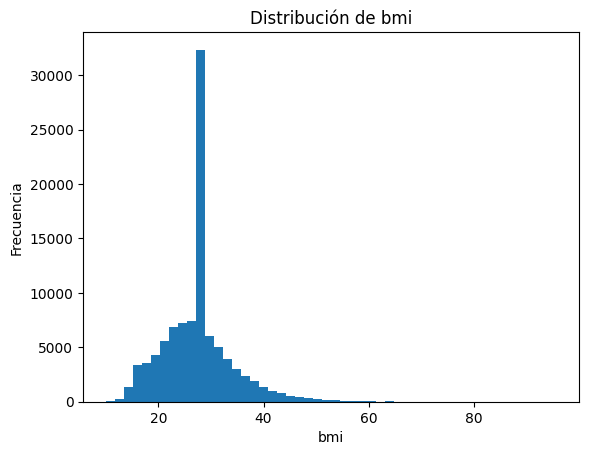

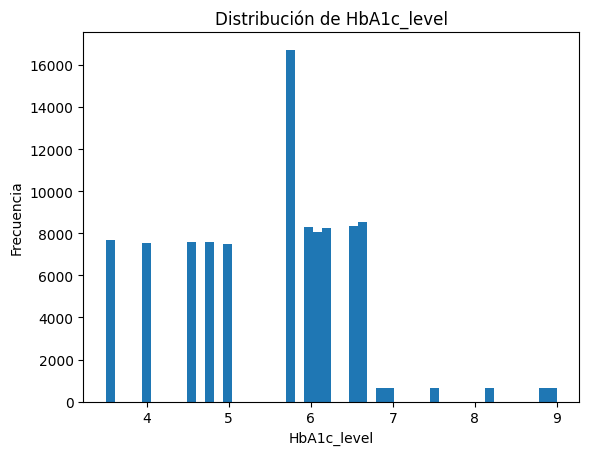

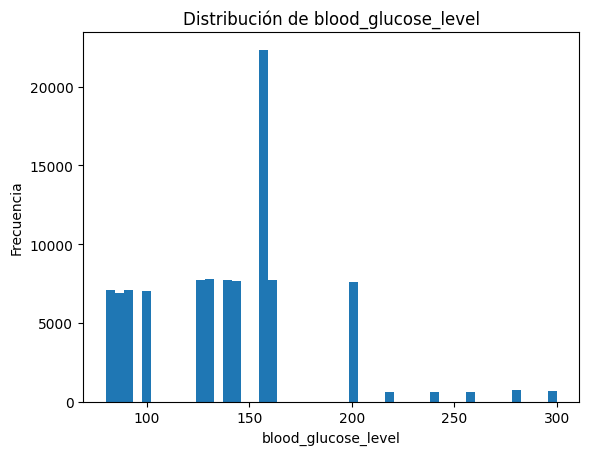

In [17]:
columnas = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

for col in columnas:
    plt.hist(df[col], bins=50); #grafica de la columna actual en 50 barritas/contenedores para ver mejor la distribución
    plt.title(f'Distribución de {col}');
    plt.xlabel(col);
    plt.ylabel('Frecuencia');
    plt.show(); 

#### Notamos que las características de nivel de hemoglobina y nivel de glucosa en la sangre no están aportando, por tanto las descartamos para el entrenamiento del modelo.

### 6.2 Boxplots de características separadas por especie.

C:\Users\InesL\AppData\Local\Temp\ipykernel_9784\595892627.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df_col, x='diabetes', y='Valor', col='Métrica', kind='box', col_wrap=3, palette='Set2', height=4, aspect=1.2, sharey=False); #sharey es para que cada gráfico tenga su propia escala en el eje y


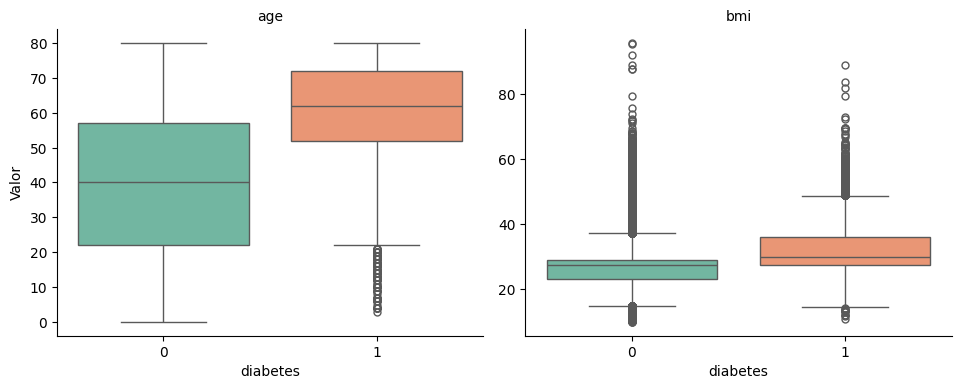

In [18]:
columnas = ['age', 'bmi']; #columnas de datos numericos a comparar

df_col = df.melt(id_vars=['diabetes'], value_vars=columnas, var_name='Métrica', value_name='Valor'); #tabla para comparar los valores numéricos de las columnas acorde al género de las personas

g = sns.catplot(data=df_col, x='diabetes', y='Valor', col='Métrica', kind='box', col_wrap=3, palette='Set2', height=4, aspect=1.2, sharey=False); #sharey es para que cada gráfico tenga su propia escala en el eje y
#seaborn asigna  para el género un color, en el caso final que vemos del boxplot se muestra verde con diabetes negativa y 1 con diabetes positiva
#catplot es para hacer varias graficas y colwrap para hacerlo de 3 columnas cada fila

g.set_titles("{col_name}"); #titulo de cada boxplot con su columna correspondiente
plt.show(); #para mostrar los gráficos

### 6.3 Eliminamos los valores atípicos de las columnas de age y del índice de masa corporal (bmi)

In [19]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

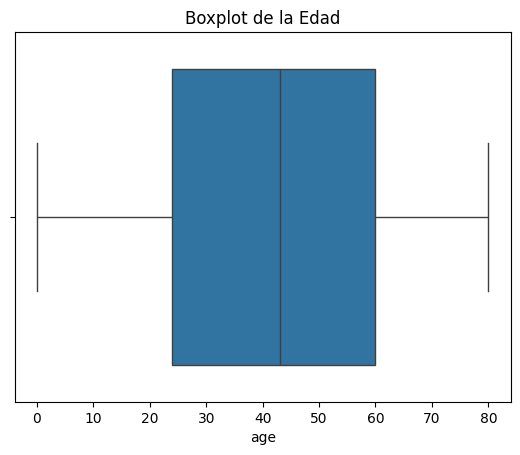

100000


In [21]:
sns.boxplot(x=df['age'])
plt.title('Boxplot de la Edad')
plt.show()
print(len(df['age']))

In [22]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]

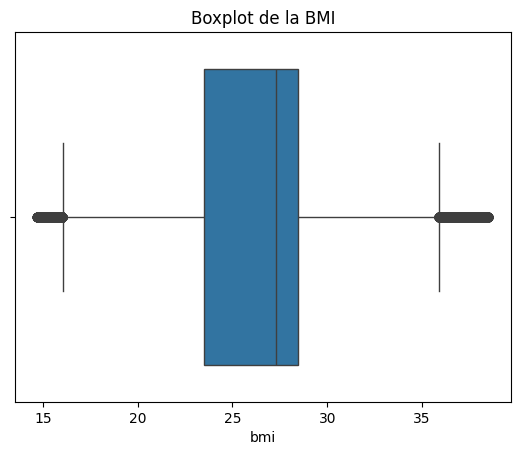

92914


In [23]:
sns.boxplot(x=df['bmi'])
plt.title('Boxplot de la BMI')
plt.show()
print(len(df['bmi']))

### 6.4 Gráficos de dispersión y matriz de correlación entre pares de características (pairplot de Seaborn).
### variable objetivo: diabetes para saber si en base a los datos que usamos, las personas tienen o no diabetes, la columna no es utilizada y es binaria

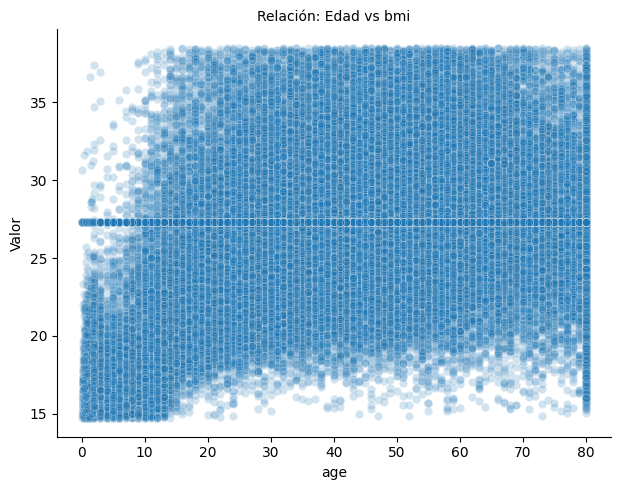

In [24]:
variables = ['bmi'];

df_scatter = df.melt(id_vars=['age'], value_vars=variables, var_name='Métrica', value_name='Valor'); #los valores estan relacionados con age

g = sns.FacetGrid(df_scatter, col="Métrica", col_wrap=2, height=5, aspect=1.2, sharey=False); #uso de seaborn para hacer 2 gráficas por cada relación, aspect 1.2 es para realizar un rectangulo un poco ancho
g.map(sns.scatterplot, "age", "Valor", alpha=0.2);

g.set_titles("Relación: Edad vs {col_name}");
plt.show();

## 7 Análisis de la base de datos

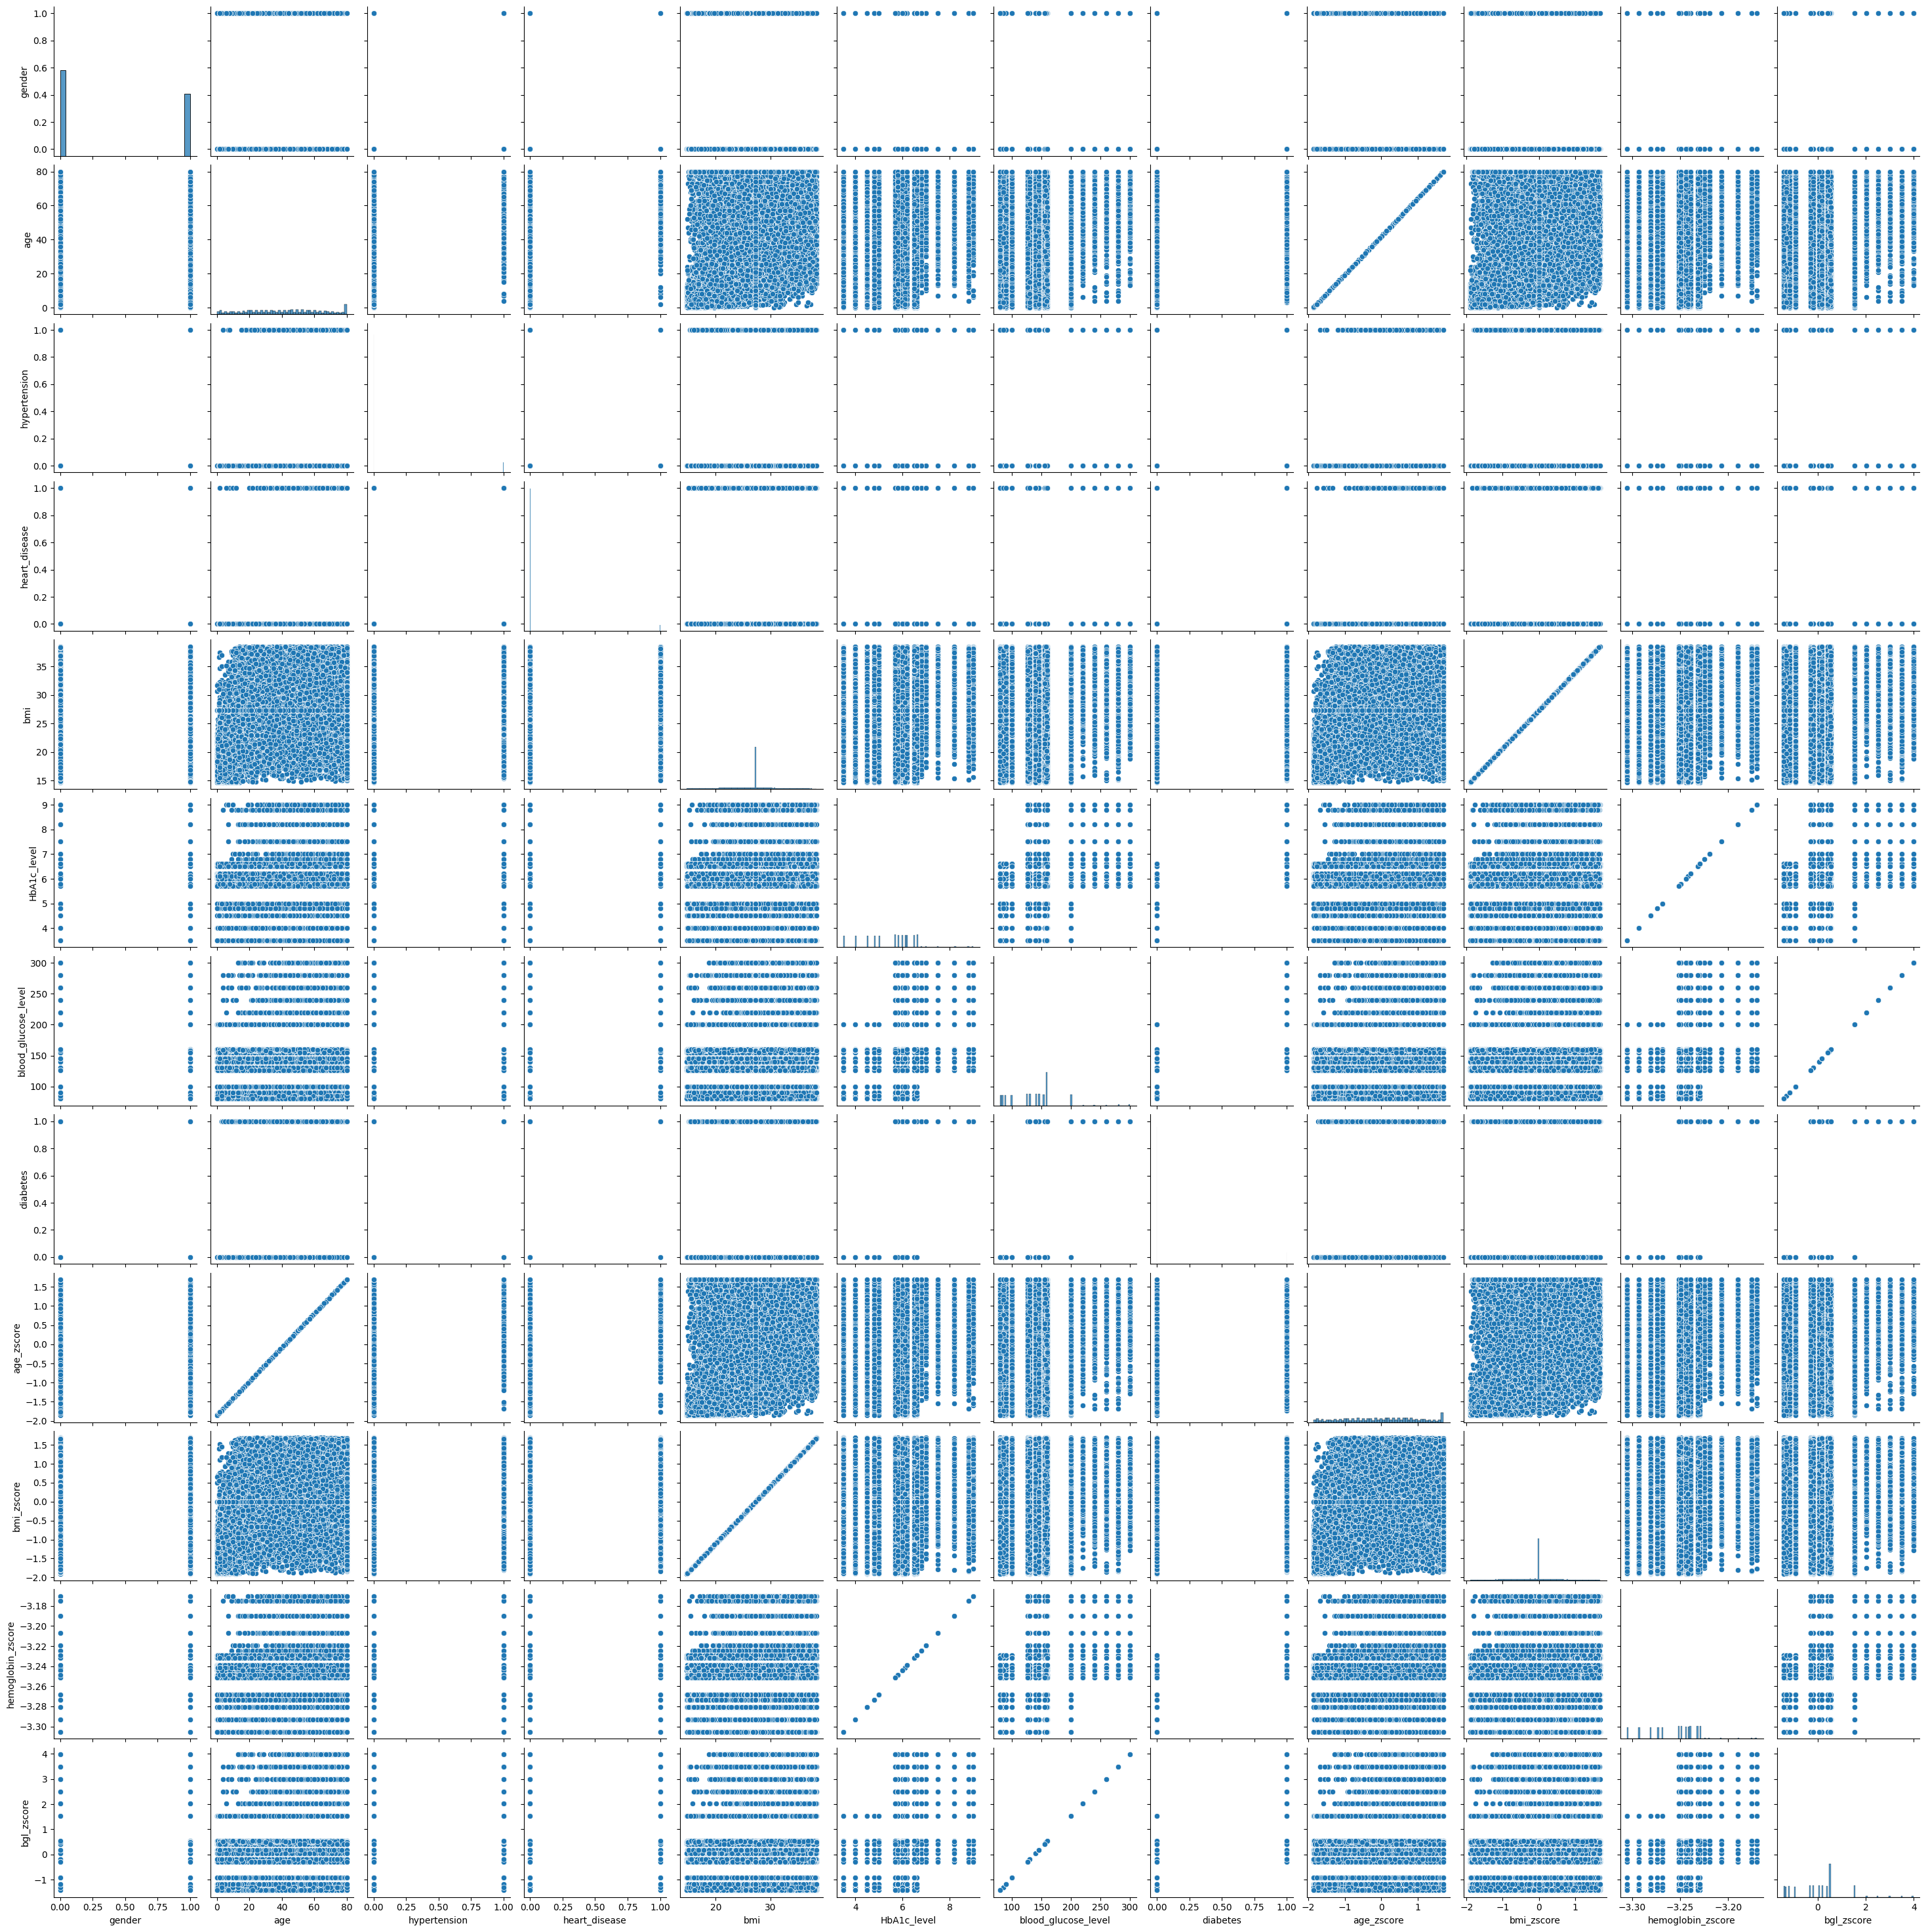

In [25]:
dat = df
sns.pairplot(dat)
plt.show()